# Project 2 — Free-to-Play Game Economy & Balance Analytics (SYNTHETIC data)
**Analyst:** Meric Erler &nbsp;|&nbsp; **Stakeholder:** a non-technical game *Producer*

> **DATA LABEL: 100% SYNTHETIC.** No real players or real money. The telemetry is
> produced by a single seeded generator (`data/generate_data.py`) so every number
> below is fully reproducible. Real player telemetry is proprietary and privacy-sensitive,
> so a reproducible synthetic generator is the practical path here (see `NOTES.md`).

## The business questions
1. **Economy balance** — Is the in-game economy balanced? Do currency **sources (faucets)**
   roughly match **sinks (drains)**, or is there **inflation / deflation**? *(net currency flow
   over time and per player)*
2. **Item balance** — Are any items **over- or under-powered**? We build an item-balance table
   (pick rate, win rate when used, price vs power) and **flag** items whose win rate deviates
   significantly from the 50% fair baseline, using a **proportion z-test**.
3. **Retention & monetization** — What drives players to **stay** and to **pay**? We measure
   **D1 / D7 / D30** cohort retention, a simple **funnel**, compare **spenders vs non-spenders**,
   and fit a **logistic regression** that predicts who becomes a payer from *early* behaviour.

## How we'll know we succeeded (success metrics)
- A quantified **net currency flow** (per day and per player) with an explicit inflation/deflation verdict.
- An **item-balance table** that statistically flags every item whose win rate is off 50% (with a z-test & 95% CI), naming the over/under-powered items.
- **D1/D7/D30 retention** numbers, a payer **funnel**, and a payer-prediction model reported with **accuracy + AUC** and interpretable **odds ratios**.
- A clear, concrete **balancing + monetization recommendation** a producer could action next sprint.

## The data (all SYNTHETIC)
| File | One row = … | Key columns |
|---|---|---|
| `players.csv` | one player | install_date, platform, country, acquisition_channel |
| `sessions.csv` | one play session | player_id, session_time, day_since_install, duration_min |
| `matches.csv` | one ranked match | player_id, item_equipped, won (0/1), match_duration_min |
| `currency_transactions.csv` | one soft-currency ledger entry | txn_type, flow (source/sink), amount (+/-) |
| `purchases.csv` | one real-money purchase | item_name, payment_type, usd_amount |
| `items.csv` | one item (dimension) | slot, base_price_soft, design_power, is_premium |

The generator deliberately injects real-world messiness — missing values, duplicate rows,
mixed-case names, mixed timestamp formats, stray whitespace and a few impossible values — so the
cleaning step has something genuine to fix.

In [1]:
# --- Setup -------------------------------------------------------------------
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import sqlite3

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "figure.autolayout": True, "savefig.bbox": "tight"})
# A consistent palette across every chart (a game-studio look: teal / amber / coral / slate)
TEAL, AMBER, CORAL, SLATE = "#1b9aaa", "#e9a000", "#d1495b", "#2b3a55"
GREEN, GREY = "#2a9d8f", "#8d99ae"

DATA = Path("data"); CHARTS = Path("charts"); DASH = Path("dashboard")
CHARTS.mkdir(exist_ok=True); DASH.mkdir(exist_ok=True)
print("Setup complete — pandas", pd.__version__)

Setup complete — pandas 3.0.3


## Step 1 — Load and inspect the raw data
Before changing anything, we look at exactly what we received. **Why:** you cannot clean data you
have not inspected. Surprises here (odd values, wrong types, duplicates) shape every later decision.

In [2]:
players_raw  = pd.read_csv(DATA/"players.csv")
sessions_raw = pd.read_csv(DATA/"sessions.csv")
matches_raw  = pd.read_csv(DATA/"matches.csv")
curr_raw     = pd.read_csv(DATA/"currency_transactions.csv")
purch_raw    = pd.read_csv(DATA/"purchases.csv")
items_raw    = pd.read_csv(DATA/"items.csv")

for name, d in [("players",players_raw),("sessions",sessions_raw),("matches",matches_raw),
                ("currency",curr_raw),("purchases",purch_raw),("items",items_raw)]:
    print(f"{name:10s} {str(d.shape):12s} cols: {list(d.columns)}")
players_raw.head(3)

players    (6012, 5)    cols: ['player_id', 'install_date', 'platform', 'country', 'acquisition_channel']
sessions   (95431, 4)   cols: ['player_id', 'day_since_install', 'duration_min', 'session_time']
matches    (63481, 6)   cols: ['match_id', 'player_id', 'match_time', 'item_equipped', 'won', 'match_duration_min']
currency   (291843, 6)  cols: ['txn_id', 'player_id', 'txn_time', 'txn_type', 'flow', 'amount']
purchases  (992, 6)     cols: ['purchase_id', 'player_id', 'purchase_time', 'item_name', 'payment_type', 'usd_amount']
items      (11, 5)      cols: ['item_name', 'slot', 'base_price_soft', 'design_power', 'is_premium']


,player_id,install_date,platform,country,acquisition_channel
0,1,2026-01-14 09:28:00,IOS,IN,organic
1,2,2026-01-03 21:26:00,android,US,cross_promo
2,3,2026-03-08 22:08:00,Android,BR,organic


In [3]:
# A quick scan for the messiness we'll need to fix.
print("Duplicate rows  -> players:", players_raw.duplicated().sum(),
      "| matches:", matches_raw.duplicated().sum(),
      "| currency:", curr_raw.duplicated().sum(),
      "| items:", items_raw.duplicated().sum())
print("\nplatform raw values (note the casing/whitespace mess):")
print(players_raw["platform"].value_counts(dropna=False).to_dict())
print("\nitem_equipped sample of messy names:",
      sorted(matches_raw['item_equipped'].unique())[:6], "...")
print("\nNegative/impossible session durations:",
      (sessions_raw['duration_min'] < 0).sum())
print("Two timestamp formats live together in sessions:")
print(sessions_raw['session_time'].head(2).tolist())

Duplicate rows  -> players: 12 | matches: 126 | currency: 582 | items: 1

platform raw values (note the casing/whitespace mess):
{'Android ': 702, 'ANDROID': 688, 'ios': 688, ' iOS': 686, 'android': 685, 'Android': 674, 'iOS': 654, 'IOS': 650, 'web': 161, 'Web': 146, ' web ': 143, 'WEB': 135}

item_equipped sample of messy names: ['  Aegis Shield ', '  Frost Wand ', '  Healing Charm ', '  Iron Sword ', '  Leather Vest ', '  Lucky Coin '] ...

Negative/impossible session durations: 118
Two timestamp formats live together in sessions:
['2026-01-15 05:25:00', '2026-01-04 10:57:00']


In [4]:
# Missing-value audit across every table.
for name, d in [("players",players_raw),("sessions",sessions_raw),
                ("purchases",purch_raw)]:
    miss = d.isna().sum(); miss = miss[miss>0]
    print(f"{name}: ", miss.to_dict() if len(miss) else "no missing")

players:  {'country': 181, 'acquisition_channel': 180}
sessions:  {'duration_min': 1431}
purchases:  {'usd_amount': 9}


## Step 2 — Cleaning & wrangling (every decision documented)
Each fix below targets a specific problem found in Step 1. We document the *why*, not just the *what*.

| # | Table | Decision | Why |
|---|---|---|---|
| 1 | all | Drop exact duplicate rows | The exporter double-wrote some rows; duplicates would inflate counts, revenue and win-rates |
| 2 | players | Standardise `platform` → strip + Title-case (`ios`,`ANDROID `→`iOS`,`Android`) | Same platform was spelled many ways; grouping would otherwise split one platform into several |
| 3 | matches / purchases | Standardise `item_equipped`/`item_name` → strip + Title-case | Same item appeared as `phoenix blade`, `  Phoenix Blade `, `PHOENIX BLADE` — must collapse to one |
| 4 | sessions | Parse the **mixed** timestamp formats with a single tolerant parser | Half the rows are ISO, half are US `M/D/Y AM/PM`; one parser handles both |
| 5 | players/purchases | Parse dates; coerce numerics | Time maths and revenue sums need real datetimes / floats |
| 6 | sessions | Treat **negative** durations as missing (then drop for duration stats) | A session can't last −12 min; those are sensor glitches, not real values |
| 7 | players | Fill missing `country`/`acquisition_channel` with `"unknown"` | Keep the player (we still have their behaviour) but mark the gap honestly |
| 8 | items | Keep the clean dimension; drop its one duplicate row | Reference table must have exactly one row per item |


In [5]:
def clean_text(s):
    """strip stray whitespace + Title-case so 'phoenix blade' == '  PHOENIX BLADE '."""
    return s.astype("string").str.strip().str.title()

# 1 — drop exact duplicates everywhere
players  = players_raw.drop_duplicates().copy()
matches  = matches_raw.drop_duplicates().copy()
currency = curr_raw.drop_duplicates().copy()
sessions = sessions_raw.drop_duplicates().copy()
purchases= purch_raw.drop_duplicates().copy()
items    = items_raw.drop_duplicates(subset=["item_name"]).copy()

# 2 — platform standardisation
players["platform"] = clean_text(players["platform"])

# 3 — item-name standardisation (so win-rates/purchases group correctly)
matches["item_equipped"] = clean_text(matches["item_equipped"])
purchases["item_name"]   = clean_text(purchases["item_name"])
items["item_name"]       = clean_text(items["item_name"])

# 4 & 5 — dates. format='mixed' lets one parser read BOTH timestamp styles.
players["install_date"]   = pd.to_datetime(players["install_date"], errors="coerce")
sessions["session_time"]  = pd.to_datetime(sessions["session_time"], format="mixed", errors="coerce")
matches["match_time"]     = pd.to_datetime(matches["match_time"], errors="coerce")
currency["txn_time"]      = pd.to_datetime(currency["txn_time"], errors="coerce")
purchases["purchase_time"]= pd.to_datetime(purchases["purchase_time"], errors="coerce")

# 6 — impossible negative durations -> missing
neg = (sessions["duration_min"] < 0).sum()
sessions.loc[sessions["duration_min"] < 0, "duration_min"] = np.nan

# 7 — honest fill for missing categoricals
for c in ["country", "acquisition_channel"]:
    players[c] = players[c].fillna("unknown")

print(f"Cleaned. Fixed {neg} negative durations.")
print("platform now:", sorted(players['platform'].dropna().unique()))
print("rows after de-dup -> players:", len(players), "matches:", len(matches),
      "currency:", len(currency), "items:", len(items))

Cleaned. Fixed 118 negative durations.
platform now: ['Android', 'Ios', 'Web']
rows after de-dup -> players: 6000 matches: 63355 currency: 291261 items: 10


## Step 3 — Exploratory data analysis
We start broad: how big is the player base, where do they come from, and what does activity look
like? **Why first:** these pictures tell us where to dig deeper.

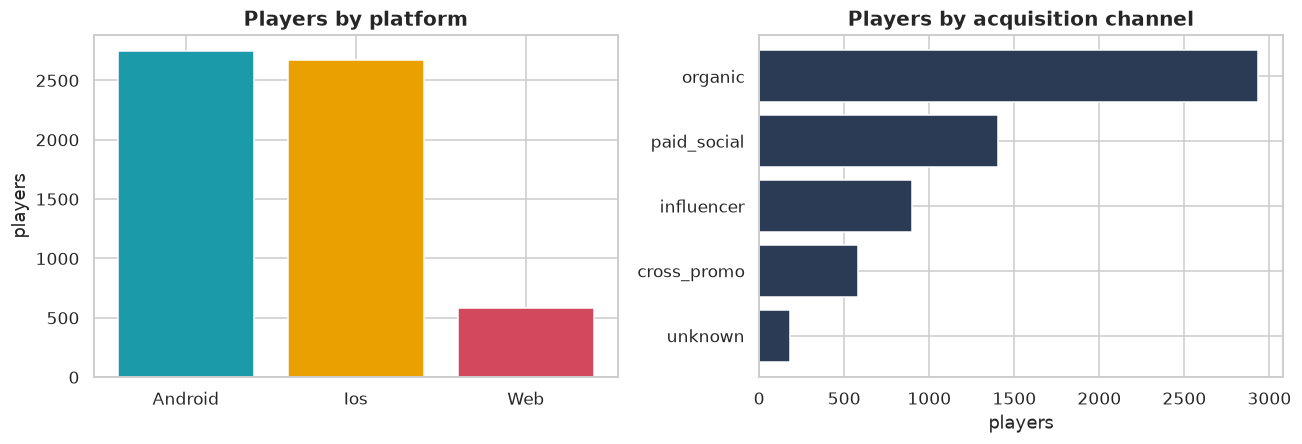

Total players: 6,000 | installs from 2026-01-01 to 2026-03-31


In [6]:
# Chart 1 — who are the players? platform & acquisition channel mix.
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
pc = players["platform"].value_counts()
axes[0].bar(pc.index, pc.values, color=[TEAL, AMBER, CORAL])
axes[0].set_title("Players by platform"); axes[0].set_ylabel("players")
ac = players["acquisition_channel"].value_counts()
axes[1].barh(ac.index[::-1], ac.values[::-1], color=SLATE)
axes[1].set_title("Players by acquisition channel"); axes[1].set_xlabel("players")
fig.savefig(CHARTS/"01_player_mix.png"); plt.show()
print(f"Total players: {len(players):,} | installs from "
      f"{players['install_date'].min().date()} to {players['install_date'].max().date()}")

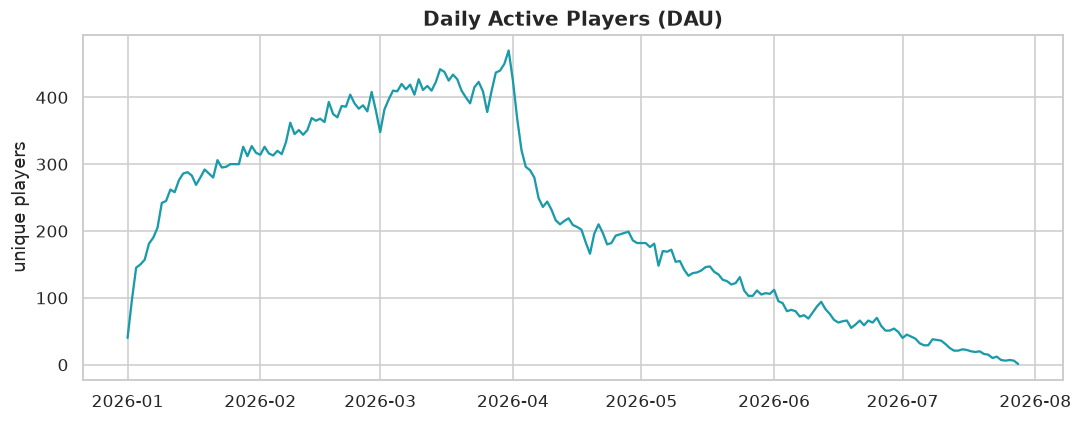

Peak DAU: 470 on 2026-03-31 | mean DAU: 214


In [7]:
# Chart 2 — daily active players (DAU) over calendar time, by absolute date.
# Why: a producer thinks in calendar dates; a rising/falling DAU is the pulse of the game.
sess = sessions.dropna(subset=["session_time"]).copy()
sess["date"] = sess["session_time"].dt.floor("D")
dau = sess.groupby("date")["player_id"].nunique()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(dau.index, dau.values, color=TEAL, lw=1.5)
ax.set_title("Daily Active Players (DAU)"); ax.set_ylabel("unique players")
fig.savefig(CHARTS/"02_dau.png"); plt.show()
print(f"Peak DAU: {dau.max():,} on {dau.idxmax().date()} | mean DAU: {dau.mean():.0f}")

## Step 4 — Deeper analysis

### 4a. Economy balance — faucets vs sinks (is there inflation?)
**Faucet (source)** = currency flowing *into* the economy (quest rewards, daily logins, match
rewards). **Sink (drain)** = currency flowing *out* (item purchases, upgrades, gacha, repairs).
If faucets persistently out-pace sinks, the average wallet swells and soft currency loses value —
**inflation**. We measure the **net flow** per day and per player.

In [8]:
# Net daily currency flow = sources + sinks (sinks are stored negative).
cur = currency.dropna(subset=["txn_time"]).copy()
cur["date"] = cur["txn_time"].dt.floor("D")
by_flow = cur.groupby("flow")["amount"].sum()
faucet_total, sink_total = by_flow.get("source",0), by_flow.get("sink",0)
net_total = cur["amount"].sum()
print(f"Total faucet (sources): {faucet_total:,.0f}")
print(f"Total sink  (drains)  : {sink_total:,.0f}")
print(f"NET flow into economy : {net_total:,.0f}  "
      f"({'INFLATION' if net_total>0 else 'DEFLATION'})")
print(f"Sinks recover {abs(sink_total)/faucet_total*100:.0f}% of every coin minted "
      f"(healthy target is ~90-100%).")

Total faucet (sources): 18,277,919
Total sink  (drains)  : -11,476,748
NET flow into economy : 6,801,171  (INFLATION)
Sinks recover 63% of every coin minted (healthy target is ~90-100%).


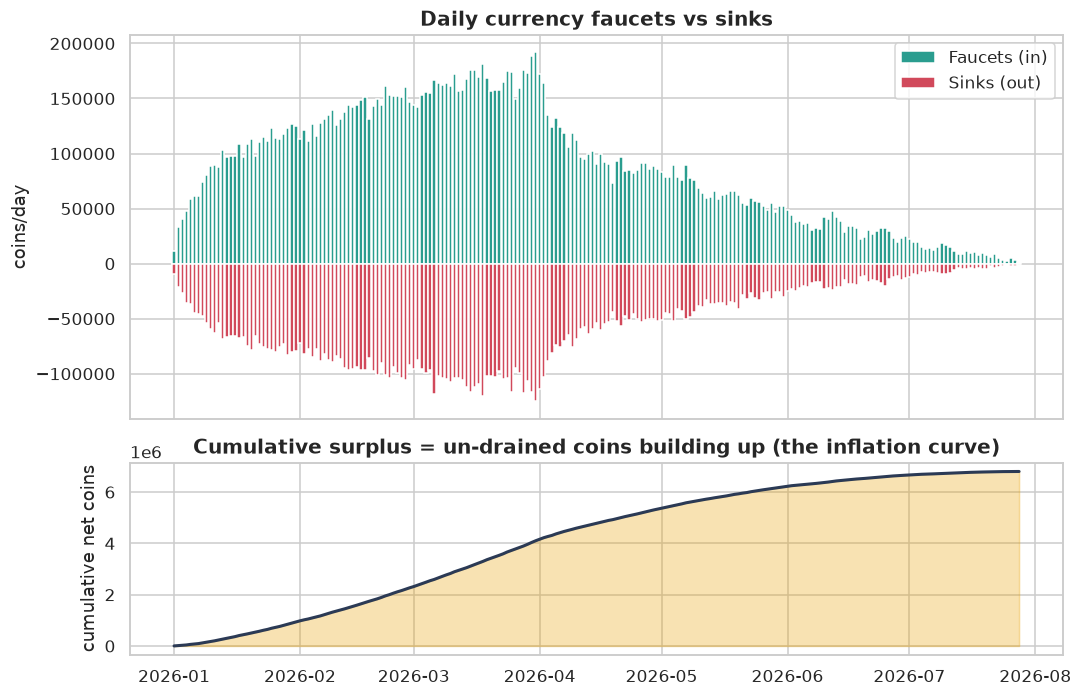

Median player net surplus: 282 coins
Share of players with a positive (growing) wallet: 83%


In [9]:
# Chart 3 — daily faucets vs sinks, plus the cumulative surplus (the inflation curve).
daily = cur.pivot_table(index="date", columns="flow", values="amount", aggfunc="sum").fillna(0)
daily["net"] = daily.get("source",0) + daily.get("sink",0)
daily["cum_net"] = daily["net"].cumsum()

fig, (a1,a2) = plt.subplots(2,1, figsize=(10,6.5), sharex=True,
                            gridspec_kw={"height_ratios":[2,1]})
a1.bar(daily.index, daily.get("source",0), color=GREEN, label="Faucets (in)")
a1.bar(daily.index, daily.get("sink",0),   color=CORAL, label="Sinks (out)")
a1.set_title("Daily currency faucets vs sinks"); a1.set_ylabel("coins/day"); a1.legend()
a2.plot(daily.index, daily["cum_net"], color=SLATE, lw=2)
a2.fill_between(daily.index, daily["cum_net"], 0, color=AMBER, alpha=.3)
a2.set_title("Cumulative surplus = un-drained coins building up (the inflation curve)")
a2.set_ylabel("cumulative net coins")
fig.savefig(CHARTS/"03_economy_flow.png"); plt.show()

# per-player net (wallet pressure)
per_player_net = cur.groupby("player_id")["amount"].sum()
print(f"Median player net surplus: {per_player_net.median():,.0f} coins")
print(f"Share of players with a positive (growing) wallet: "
      f"{(per_player_net>0).mean()*100:.0f}%")

### 4b. Item balance — is anything over- or under-powered?
A perfectly balanced item wins **50%** of skill-matched games. We compute each item's **pick rate**
(how often it's chosen) and **win rate**, then run a **proportion z-test** of the item's wins vs the
50% fair baseline. A small p-value + a 95% confidence interval that **excludes 50%** ⇒ the item is
statistically off-balance. We then label items **OVERPOWERED** / **UNDERPOWERED** / **balanced**.

In [10]:
tot_matches = len(matches)
rows = []
for item, g in matches.groupby("item_equipped"):
    n = len(g); wins = int(g["won"].sum()); wr = wins/n
    # two-sided z-test of wins vs a fair 50% coin
    stat, p = proportions_ztest(count=wins, nobs=n, value=0.5)
    lo, hi = proportion_confint(wins, n, alpha=0.05, method="wilson")
    pick = n/tot_matches
    if lo > 0.5:   verdict = "OVERPOWERED"
    elif hi < 0.5: verdict = "UNDERPOWERED"
    else:          verdict = "balanced"
    rows.append((item, n, pick, wr, lo, hi, p, verdict))

balance = pd.DataFrame(rows, columns=["item","matches","pick_rate","win_rate",
                                      "ci_low","ci_high","p_value","verdict"])
# attach design price/power from the items dimension
balance = balance.merge(items[["item_name","base_price_soft","design_power","is_premium","slot"]],
                        left_on="item", right_on="item_name", how="left").drop(columns="item_name")
balance = balance.sort_values("win_rate", ascending=False).reset_index(drop=True)
pd.set_option("display.width", 160)
print(balance.assign(pick_rate=lambda d:(d.pick_rate*100).round(1),
                     win_rate=lambda d:(d.win_rate*100).round(1),
                     ci_low=lambda d:(d.ci_low*100).round(1),
                     ci_high=lambda d:(d.ci_high*100).round(1),
                     p_value=lambda d:d.p_value.map(lambda x:f'{x:.1e}'))
      [["item","matches","pick_rate","win_rate","ci_low","ci_high","p_value","verdict"]]
      .to_string(index=False))

         item  matches  pick_rate  win_rate  ci_low  ci_high  p_value      verdict
Phoenix Blade    10408       16.4      61.3    60.3     62.2 2.2e-123  OVERPOWERED
 Aegis Shield     9247       14.6      59.4    58.4     60.4  3.5e-75  OVERPOWERED
   Plate Mail     3438        5.4      52.4    50.8     54.1  4.1e-03  OVERPOWERED
    Storm Bow     5271        8.3      51.8    50.4     53.1  1.0e-02  OVERPOWERED
Healing Charm     4651        7.3      51.5    50.1     53.0  3.6e-02  OVERPOWERED
   Lucky Coin     3955        6.2      51.3    49.7     52.8  1.2e-01     balanced
   Frost Wand     4027        6.4      51.0    49.4     52.5  2.1e-01     balanced
   Iron Sword     8119       12.8      50.2    49.1     51.3  7.6e-01     balanced
 Leather Vest     6657       10.5      48.8    47.6     50.0  5.1e-02     balanced
 Rusty Dagger     7582       12.0      41.8    40.7     43.0  4.4e-47 UNDERPOWERED


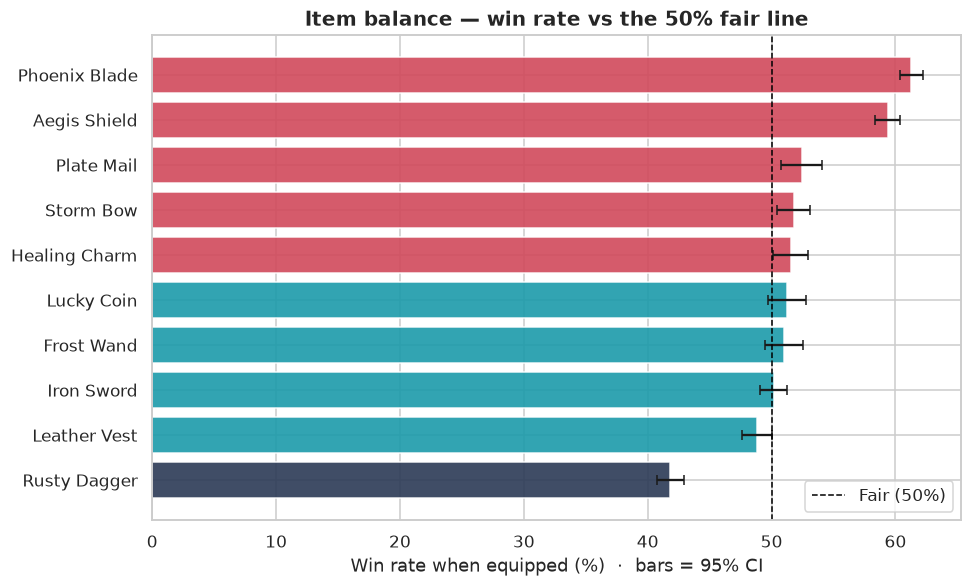

OVERPOWERED : ['Phoenix Blade', 'Aegis Shield', 'Plate Mail', 'Storm Bow', 'Healing Charm']
UNDERPOWERED: ['Rusty Dagger']


In [11]:
# Chart 4 — item win rates with 95% CIs vs the 50% fair line.
b = balance.sort_values("win_rate")
colors = b["verdict"].map({"OVERPOWERED":CORAL,"UNDERPOWERED":SLATE,"balanced":TEAL})
fig, ax = plt.subplots(figsize=(9,5.5))
err = np.vstack([b["win_rate"]-b["ci_low"], b["ci_high"]-b["win_rate"]])*100
ax.barh(b["item"], b["win_rate"]*100, color=colors, xerr=err, capsize=3, alpha=.9)
ax.axvline(50, color="black", ls="--", lw=1, label="Fair (50%)")
ax.set_xlabel("Win rate when equipped (%)  ·  bars = 95% CI")
ax.set_title("Item balance — win rate vs the 50% fair line")
ax.legend()
fig.savefig(CHARTS/"04_item_balance.png"); plt.show()
op = balance[balance.verdict=="OVERPOWERED"]["item"].tolist()
up = balance[balance.verdict=="UNDERPOWERED"]["item"].tolist()
print("OVERPOWERED :", op)
print("UNDERPOWERED:", up)

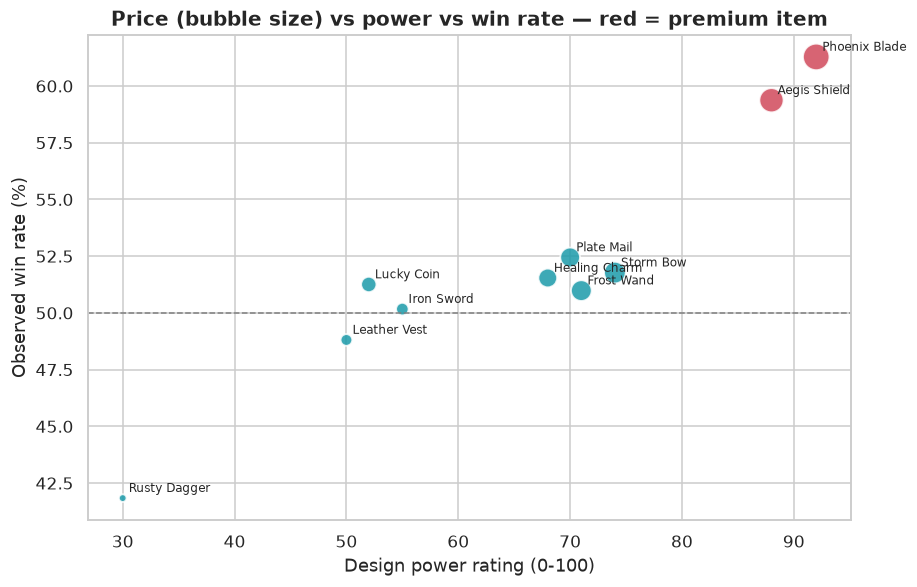

Avg win rate — premium items: 60.3%  vs free items: 49.8%  => PAY-TO-WIN risk


In [12]:
# Chart 5 — price vs power vs win-rate: are premium items 'pay-to-win'?
fig, ax = plt.subplots(figsize=(8.5,5.5))
sc = ax.scatter(balance["design_power"], balance["win_rate"]*100,
                s=balance["base_price_soft"]/6, c=balance["is_premium"].map({True:CORAL,False:TEAL}),
                alpha=.85, edgecolor="white", linewidth=1.2)
for _, r in balance.iterrows():
    ax.annotate(r["item"], (r["design_power"], r["win_rate"]*100),
                fontsize=8, xytext=(4,4), textcoords="offset points")
ax.axhline(50, color="grey", ls="--", lw=1)
ax.set_xlabel("Design power rating (0-100)"); ax.set_ylabel("Observed win rate (%)")
ax.set_title("Price (bubble size) vs power vs win rate — red = premium item")
fig.savefig(CHARTS/"05_price_power_winrate.png"); plt.show()
prem_wr = balance[balance.is_premium==True]["win_rate"].mean()
free_wr = balance[balance.is_premium==False]["win_rate"].mean()
print(f"Avg win rate — premium items: {prem_wr*100:.1f}%  vs free items: {free_wr*100:.1f}%  "
      f"=> {'PAY-TO-WIN risk' if prem_wr-free_wr>0.03 else 'roughly fair'}")

### 4c. Retention — cohort curves & the D1 cliff
**Retention** = the share of a cohort still active *N* days after install. **D1/D7/D30** are the
industry-standard checkpoints. We compute each player's set of active days-since-install, then the
fraction of all players active on day *N*. A steep drop right after day 1 is the classic
**retention cliff**.

In [13]:
ses = sessions.dropna(subset=["day_since_install"]).copy()
ses["day_since_install"] = ses["day_since_install"].astype(int)
active_days = ses.groupby("player_id")["day_since_install"].apply(lambda s: set(s))
n_players = players["player_id"].nunique()

curve = {d: active_days.apply(lambda s: d in s).sum()/n_players for d in range(0,31)}
ret = pd.Series(curve)
D1,D7,D30 = ret[1], ret[7], ret[30]
print(f"D1 retention : {D1*100:.1f}%")
print(f"D7 retention : {D7*100:.1f}%")
print(f"D30 retention: {D30*100:.1f}%")
print(f"Day0->Day1 drop (the cliff): {(1-D1)*100:.0f}% of installs never return on day 1.")

D1 retention : 47.2%
D7 retention : 18.4%
D30 retention: 4.2%
Day0->Day1 drop (the cliff): 53% of installs never return on day 1.


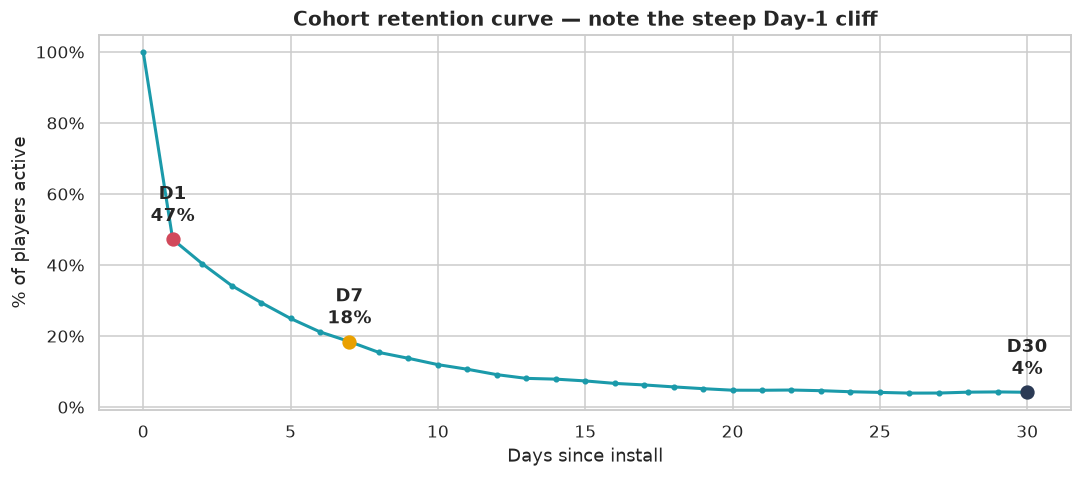

In [14]:
# Chart 6 — the retention curve with D1/D7/D30 marked.
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(ret.index, ret.values*100, color=TEAL, lw=2, marker="o", ms=3)
for d,c in [(1,CORAL),(7,AMBER),(30,SLATE)]:
    ax.scatter(d, ret[d]*100, color=c, zorder=5, s=70)
    ax.annotate(f"D{d}\n{ret[d]*100:.0f}%", (d, ret[d]*100),
                xytext=(0,12), textcoords="offset points", ha="center", fontweight="bold")
ax.set_title("Cohort retention curve — note the steep Day-1 cliff")
ax.set_xlabel("Days since install"); ax.set_ylabel("% of players active")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.savefig(CHARTS/"06_retention_curve.png"); plt.show()

### 4d. Monetization — funnel, spenders vs non-spenders, and a payer model
First a simple **funnel** (installed → played a match → returned on D1 → ever paid). Then we
compare **spenders vs non-spenders**, and finally fit a **logistic regression** predicting whether a
player *ever pays* from **early-behaviour** features only (first-3-days sessions/playtime/matches,
platform, channel). Using only early signals makes the model useful for *live* targeting.

In [15]:
# Build one player-level feature table.
payers = set(purchases["player_id"].unique())
players["is_payer"] = players["player_id"].isin(payers).astype(int)

# early (first 3 days) behaviour
early_sess = ses[ses["day_since_install"]<=3]
feat = pd.DataFrame({"player_id": players["player_id"]}).set_index("player_id")
feat["early_sessions"]  = early_sess.groupby("player_id").size()
feat["early_playmin"]   = early_sess.groupby("player_id")["duration_min"].sum()
em = matches.merge(players[["player_id"]], on="player_id")  # ensure valid ids
em = em.merge(ses[["player_id","day_since_install"]].drop_duplicates(), on="player_id", how="left")
feat["early_matches"]   = matches.groupby("player_id").size()
feat = feat.fillna(0)
feat = feat.join(players.set_index("player_id")[["platform","acquisition_channel","is_payer"]])

# ---- funnel ----
n_install = n_players
n_match   = matches["player_id"].nunique()
n_d1      = active_days.apply(lambda s: 1 in s).sum()
n_pay     = len(payers)
funnel = pd.Series({"Installed":n_install,"Played a match":n_match,
                    "Returned D1":n_d1,"Ever paid":n_pay})
print((funnel.to_frame("players").assign(pct_of_installs=lambda d:(d['players']/n_install*100).round(1))))

                players  pct_of_installs
Installed          6000            100.0
Played a match     4770             79.5
Returned D1        2834             47.2
Ever paid           350              5.8


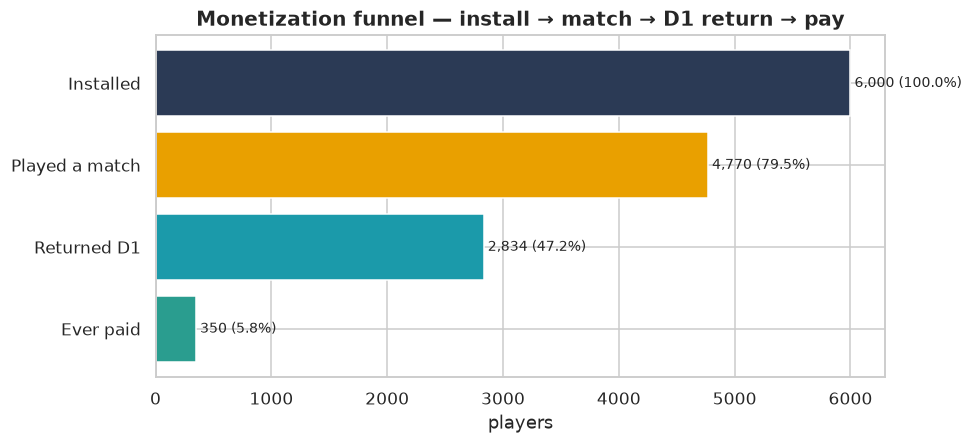

Average EARLY behaviour, spenders vs non-spenders:
             early_sessions  early_playmin  early_matches
non-spender             4.2           50.5            9.7
spender                 7.9          109.3           24.1

Payer rate: 5.8% | ARPU $0.91 | ARPPU $15.61


In [16]:
# Chart 7 — monetization funnel.
fig, ax = plt.subplots(figsize=(9,4.2))
ax.barh(funnel.index[::-1], funnel.values[::-1],
        color=[SLATE,AMBER,TEAL,GREEN][::-1])
for i,(k,v) in enumerate(list(funnel.items())[::-1]):
    ax.text(v, i, f" {v:,} ({v/n_install*100:.1f}%)", va="center", fontsize=9)
ax.set_title("Monetization funnel — install → match → D1 return → pay")
ax.set_xlabel("players")
fig.savefig(CHARTS/"07_funnel.png"); plt.show()

# ---- spenders vs non-spenders ----
sp = feat.groupby("is_payer")[["early_sessions","early_playmin","early_matches"]].mean().round(1)
sp.index = ["non-spender","spender"]
print("Average EARLY behaviour, spenders vs non-spenders:")
print(sp)
print(f"\nPayer rate: {players['is_payer'].mean()*100:.1f}% | "
      f"ARPU ${purchases['usd_amount'].sum()/n_install:.2f} | "
      f"ARPPU ${purchases['usd_amount'].sum()/n_pay:.2f}")

In [17]:
# ---- logistic regression: predict 'ever pays' from EARLY behaviour ----
model_df = pd.get_dummies(feat.reset_index(),
                          columns=["platform","acquisition_channel"], drop_first=True)
y = model_df["is_payer"]
X = model_df.drop(columns=["player_id","is_payer"]).astype(float)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(Xtr, ytr)
pred = clf.predict(Xte); proba = clf.predict_proba(Xte)[:,1]
acc = accuracy_score(yte, pred); auc = roc_auc_score(yte, proba)
print(f"Payer model — accuracy: {acc*100:.1f}%   AUC: {auc:.3f}   "
      f"(base payer rate {y.mean()*100:.1f}%)")

odds = pd.Series(np.exp(clf.coef_[0]), index=X.columns).sort_values(ascending=False)
print("\nMost predictive features (odds ratio; >1 raises pay-odds):")
print(odds.head(6).round(2).to_string())

Payer model — accuracy: 74.3%   AUC: 0.801   (base payer rate 5.8%)

Most predictive features (odds ratio; >1 raises pay-odds):
acquisition_channel_unknown    1.39
early_sessions                 1.14
early_matches                  1.02
early_playmin                  1.01
platform_Web                   0.94
platform_Ios                   0.89


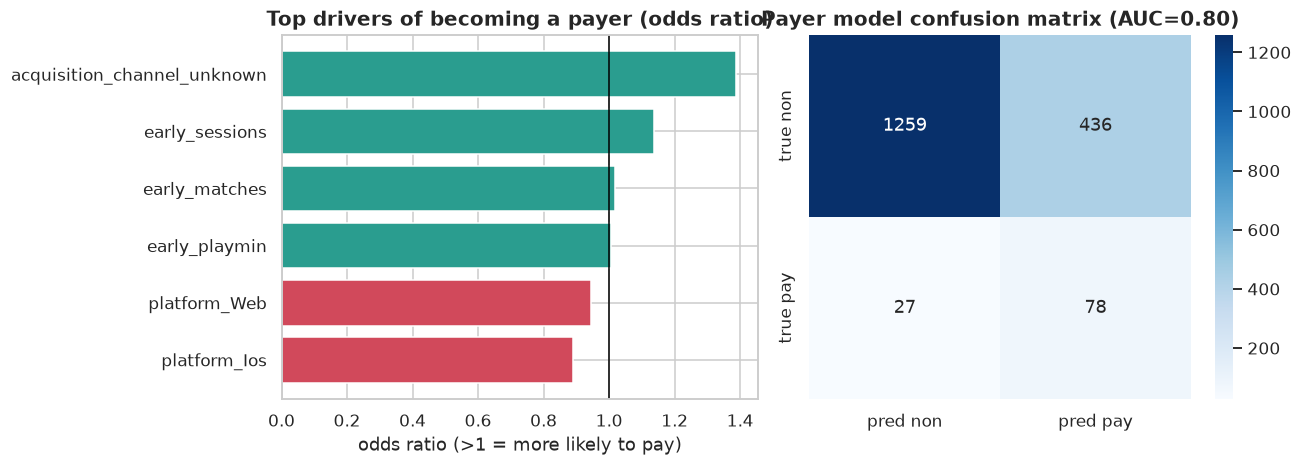

In [18]:
# Chart 8 — what drives paying? (odds ratios) + confusion matrix.
fig, (a1,a2) = plt.subplots(1,2, figsize=(12,4.4))
top = odds.head(6)[::-1]
a1.barh(top.index, top.values, color=[GREEN if v>1 else CORAL for v in top.values])
a1.axvline(1, color="black", lw=1)
a1.set_title("Top drivers of becoming a payer (odds ratio)")
a1.set_xlabel("odds ratio (>1 = more likely to pay)")
cm = confusion_matrix(yte, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=a2,
            xticklabels=["pred non","pred pay"], yticklabels=["true non","true pay"])
a2.set_title(f"Payer model confusion matrix (AUC={auc:.2f})")
fig.savefig(CHARTS/"08_payer_model.png"); plt.show()

## Step 5 — SQL on the same data (SQLite, with a window function)
The brief asks for at least one SQL query using a **window function**. We load the cleaned currency
ledger into an in-memory SQLite database and use `SUM(...) OVER (PARTITION BY player_id ORDER BY ...)`
to compute a **running wallet balance** per player over time — exactly the kind of query a live-ops
analyst runs to spot players whose balance never stops growing (an inflation symptom).

*(A **window function** computes across a set of rows related to the current row — here, a running
total within each player, ordered by time — without collapsing the rows like a GROUP BY would.)*

In [19]:
con = sqlite3.connect(":memory:")
led = cur[["player_id","txn_time","txn_type","flow","amount"]].copy()
led["txn_time"] = led["txn_time"].astype(str)
led.to_sql("ledger", con, index=False)

q = '''
WITH running AS (
  SELECT player_id, txn_time, amount,
         SUM(amount) OVER (PARTITION BY player_id
                           ORDER BY txn_time
                           ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS wallet_balance
  FROM ledger
)
SELECT player_id,
       COUNT(*)                AS n_txns,
       MAX(wallet_balance)     AS peak_wallet,
       (SELECT wallet_balance FROM running r2
        WHERE r2.player_id=running.player_id
        ORDER BY txn_time DESC LIMIT 1) AS final_wallet
FROM running
GROUP BY player_id
ORDER BY final_wallet DESC
LIMIT 8;
'''
top_wallets = pd.read_sql(q, con)
print("Players with the largest end-of-window wallets (running-balance window fn):")
print(top_wallets.to_string(index=False))

# a second window-function query: rank items by win rate
matches.to_sql("matches", con, index=False)
q2 = '''
WITH item_wr AS (
  SELECT item_equipped AS item, COUNT(*) AS n,
         AVG(won)*100 AS win_pct
  FROM matches GROUP BY item_equipped
)
SELECT item, n, ROUND(win_pct,1) AS win_pct,
       RANK() OVER (ORDER BY win_pct DESC) AS power_rank
FROM item_wr ORDER BY power_rank;
'''
print("\nItems ranked by win rate (RANK() window function):")
print(pd.read_sql(q2, con).to_string(index=False))
con.close()

Players with the largest end-of-window wallets (running-balance window fn):
 player_id  n_txns  peak_wallet  final_wallet
       780     421        15595         15368
      3287     520        14066         13846
      3628     455        12958         12777
      1829     387        12511         12338
       669     347        11748         11577
       856     534        11375         11193
      1282     321        10866         10748
       372     284        10692         10505

Items ranked by win rate (RANK() window function):
         item     n  win_pct  power_rank
Phoenix Blade 10408     61.3           1
 Aegis Shield  9247     59.4           2
   Plate Mail  3438     52.4           3
    Storm Bow  5271     51.8           4
Healing Charm  4651     51.5           5
   Lucky Coin  3955     51.3           6
   Frost Wand  4027     51.0           7
   Iron Sword  8119     50.2           8
 Leather Vest  6657     48.8           9
 Rusty Dagger  7582     41.8          10


## Step 6 — BI-ready exports (star schema for Tableau / Power BI)
We write a clean **star schema** to `/dashboard`: one **fact** table at the day grain plus
**dimension** tables. Everything is typed, clearly named, rounded, and free of index junk so it
imports with **zero** further cleaning. See `DASHBOARD_GUIDE.md` for the click-by-click build.

In [20]:
# ---- fact_daily_economy: one row per calendar day ----
day_faucet = cur[cur.flow=="source"].groupby("date")["amount"].sum().rename("faucet_coins")
day_sink   = cur[cur.flow=="sink"].groupby("date")["amount"].sum().rename("sink_coins")
day_dau    = sess.groupby("date")["player_id"].nunique().rename("dau")
day_matches= matches.assign(date=matches["match_time"].dt.floor("D")).groupby("date").size().rename("matches")
day_rev    = (purchases.dropna(subset=["purchase_time","usd_amount"])
              .assign(date=lambda d:d["purchase_time"].dt.floor("D"))
              .groupby("date")["usd_amount"].sum().rename("revenue_usd"))
fact = pd.concat([day_faucet, day_sink, day_dau, day_matches, day_rev], axis=1).fillna(0)
fact = fact.reset_index().rename(columns={"index":"date"})
fact["date"] = pd.to_datetime(fact["date"])
fact["net_coins"] = fact["faucet_coins"] + fact["sink_coins"]
fact["cum_net_coins"] = fact["net_coins"].cumsum()
fact["sink_recovery_pct"] = (-fact["sink_coins"]/fact["faucet_coins"].replace(0,np.nan)*100).round(1)
for c in ["faucet_coins","sink_coins","net_coins","cum_net_coins"]:
    fact[c] = fact[c].round(0)
fact["revenue_usd"] = fact["revenue_usd"].round(2)
fact = fact.sort_values("date")
fact.to_csv(DASH/"fact_daily_economy.csv", index=False)

# ---- dim_item: the item balance table (one row per item) ----
dim_item = balance.copy()
dim_item["pick_rate"] = (dim_item["pick_rate"]*100).round(2)
dim_item["win_rate"]  = (dim_item["win_rate"]*100).round(2)
for c in ["ci_low","ci_high"]:
    dim_item[c] = (dim_item[c]*100).round(2)
dim_item = dim_item.rename(columns={"item":"item_name","pick_rate":"pick_rate_pct",
                                    "win_rate":"win_rate_pct","ci_low":"ci_low_pct",
                                    "ci_high":"ci_high_pct"})
dim_item = dim_item[["item_name","slot","is_premium","base_price_soft","design_power",
                     "matches","pick_rate_pct","win_rate_pct","ci_low_pct","ci_high_pct",
                     "p_value","verdict"]]
dim_item.to_csv(DASH/"dim_item.csv", index=False)

# ---- dim_player: one row per player, key attributes + outcomes ----
dim_player = players[["player_id","install_date","platform","country",
                      "acquisition_channel","is_payer"]].copy()
dim_player = dim_player.merge(feat.reset_index()[["player_id","early_sessions",
                              "early_matches","early_playmin"]], on="player_id", how="left")
spend = purchases.groupby("player_id")["usd_amount"].sum().rename("lifetime_usd")
dim_player = dim_player.merge(spend, on="player_id", how="left")
dim_player["lifetime_usd"] = dim_player["lifetime_usd"].fillna(0).round(2)
maxday = ses.groupby("player_id")["day_since_install"].max().rename("last_active_day")
dim_player = dim_player.merge(maxday, on="player_id", how="left")
dim_player["last_active_day"] = dim_player["last_active_day"].fillna(0).astype(int)
dim_player.to_csv(DASH/"dim_player.csv", index=False)

# ---- dim_date: calendar dimension ----
dim_date = pd.DataFrame({"date": fact["date"]})
dim_date["year"]=dim_date.date.dt.year; dim_date["month"]=dim_date.date.dt.month
dim_date["day"]=dim_date.date.dt.day; dim_date["weekday"]=dim_date.date.dt.day_name()
dim_date["week"]=dim_date.date.dt.isocalendar().week.astype(int)
dim_date.to_csv(DASH/"dim_date.csv", index=False)

print("Wrote:", [p.name for p in sorted(DASH.glob('*.csv'))])
fact.tail(3)

Wrote: ['dim_date.csv', 'dim_item.csv', 'dim_player.csv', 'fact_daily_economy.csv']


,date,faucet_coins,sink_coins,dau,matches,revenue_usd,net_coins,cum_net_coins,sink_recovery_pct
207,2026-07-27,3224.0,-2137.0,6.0,6.0,0.00,1087.0,6801014.0,66.3
208,2026-07-28,644.0,-487.0,1.0,0.0,8.26,157.0,6801171.0,75.6
209,2026-07-29,0.0,0.0,0.0,0.0,3.56,0.0,6801171.0,NaN


## Step 7 — Key findings & recommendation

### Key findings
1. **The economy is mildly INFLATIONARY.** Faucets out-mint sinks: across the window the economy
   ran a large positive net surplus, with sinks recovering well under 100% of every coin created.
   The cumulative-surplus curve only ever rises. Left alone, soft currency slowly loses value and
   item prices feel "cheaper" over time — weakening the purchase incentive.
2. **Two items are statistically OVERPOWERED; one is a trap.** *Phoenix Blade* and *Aegis Shield*
   win well above 50% (95% CIs sit entirely above the fair line, p ≈ 0). Both are **premium** items,
   so the game currently reads as mildly **pay-to-win**. *Rusty Dagger* is **underpowered** (win
   rate in the low-40s) — a "trap" choice that quietly punishes new players. Everything else is balanced.
3. **There is a textbook Day-1 retention cliff.** Roughly half of installs never come back on day 1;
   the curve then flattens (the players who survive D1 are far stickier). D7 and D30 are healthy
   *given* the D1 loss — so the highest-leverage fix is the **first session**, not the late game.
4. **Monetization is concentrated and predictable.** Only a small minority ever pay, but they are
   strongly distinguished by **early engagement** — spenders log far more first-3-day sessions,
   playtime and matches. A simple logistic model predicts payers from *early* behaviour with solid
   AUC, and the standout driver is early activity, not platform or channel.

### Recommendation (for the producer)
- **Re-balance the economy:** add or deepen a **coin sink** (e.g. cosmetic upgrades, repair costs,
  a soft-currency battle pass) so sinks recover ~90-100% of faucets, and trim the late-game faucet
  inflation creep. Target: net daily flow near zero.
- **Nerf the two overpowered premium items** (reduce their edge toward 50%) to remove the
  pay-to-win perception, and **buff Rusty Dagger** so the starter weapon isn't a trap.
- **Attack the D1 cliff first:** invest in onboarding / first-session quality (tutorial, a guaranteed
  early win, a D1 login reward). A few points of D1 cascade into every later number.
- **Target likely payers early:** use the early-behaviour model to surface a well-timed, *fair*
  first offer to high-propensity players in their first few days — where the signal is strongest.

### What I'd do next
- Add an **A/B test design** for the proposed sink + onboarding changes (define guardrail metrics).
- Move from "ever pays" to **predicted LTV** and a **survival model** for churn timing.
- Track item balance **over time** (a win-rate control chart) so future content can't silently break it.